# 03 - Final Internal Test Comparison: Flat XGBoost vs Hierarchical IDS

This notebook compares the flat 34-class XGBoost baseline and the hierarchical IDS on the exact same canonical internal test split: `processed_data/test_data.npz`.

It answers the reviewer question: is the gain caused by the hierarchical system design, not by a different test set?


## 1. Setup and Artifact Checks

The notebook uses the internal-test outputs produced by `evaluate_internal_test_comparison.py`. Notebook 02 can regenerate those outputs when needed.


In [1]:
from pathlib import Path
import json
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 90)
pd.set_option("display.max_rows", 90)
pd.set_option("display.width", 180)

ABLATION_DIR = Path.cwd()
if ABLATION_DIR.name != "Ablation Study":
    ABLATION_DIR = Path(r"D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\Ablation Study")
PROJECT_ROOT = ABLATION_DIR.parent
WORKSPACE_ROOT = Path(r"D:\Ml Project")

INTERNAL_DIR = PROJECT_ROOT / "results" / "ablation" / "internal_test"
FLAT_DIR = PROJECT_ROOT / "results" / "ablation" / "flat"
FIGURES_DIR = PROJECT_ROOT / "results" / "ablation" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

INTERNAL_SCRIPT = ABLATION_DIR / "evaluate_internal_test_comparison.py"
TEST_NPZ_PATH = WORKSPACE_ROOT / "processed_data" / "test_data.npz"
SUMMARY_PATH = INTERNAL_DIR / "internal_test_flat_vs_hierarchical_summary.csv"
PER_CLASS_PATH = INTERNAL_DIR / "internal_test_per_class_comparison.csv"
BINARY_GATE_PATH = INTERNAL_DIR / "internal_test_binary_gate_summary.csv"
MANIFEST_PATH = INTERNAL_DIR / "internal_test_comparison_manifest.json"
HIER_PRED_PATH = INTERNAL_DIR / "hierarchical_internal_test_predictions.npz"
FLAT_PRED_PATH = FLAT_DIR / "flat_34class_test_predictions.npz"
REQUIRED_OUTPUTS = [SUMMARY_PATH, PER_CLASS_PATH, BINARY_GATE_PATH, MANIFEST_PATH, HIER_PRED_PATH]


def require_paths(paths, message="Missing required files"):
    missing = [str(Path(p)) for p in paths if not Path(p).exists()]
    if missing:
        raise FileNotFoundError(message + ":\n" + "\n".join(missing))


def load_json(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def percent_frame(df, columns, decimals=2):
    out = df.copy()
    for col in columns:
        if col in out.columns:
            out[col] = out[col].map(lambda v: f"{100 * float(v):.{decimals}f}%")
    return out


def show_table(title, df, percent_cols=None, decimals=2, max_rows=None):
    display(Markdown(f"**{title}**"))
    view = df.copy()
    if max_rows is not None:
        view = view.head(max_rows)
    if percent_cols:
        view = percent_frame(view, percent_cols, decimals=decimals)
    display(view)


def save_and_show(fig, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"Saved figure: {path}")

require_paths([TEST_NPZ_PATH, FLAT_PRED_PATH, *REQUIRED_OUTPUTS], "Internal comparison inputs are incomplete")
print("All internal-test comparison inputs are available.")


All internal-test comparison inputs are available.


## 2. Load Comparison Tables and Predictions

All metrics, per-class reports, and row-level outcomes below use the same row order and labels.


In [2]:
summary_df = pd.read_csv(SUMMARY_PATH)
per_class_df = pd.read_csv(PER_CLASS_PATH)
binary_gate_df = pd.read_csv(BINARY_GATE_PATH)
manifest = load_json(MANIFEST_PATH)

hier_npz = np.load(HIER_PRED_PATH, allow_pickle=True)
y_true = hier_npz["y_true_34class"].astype(np.int64)
y_pred = hier_npz["y_pred_34class"].astype(np.int64)
y_true_binary = hier_npz["y_true_binary"].astype(np.int64)
binary_pred = hier_npz["binary_pred"].astype(np.int64)
binary_prob = hier_npz["binary_prob"].astype(float)
confidence = hier_npz["confidence"].astype(float)
route_status = pd.Series(hier_npz["route_status"].astype(str), name="route_status")
family_pred = pd.Series(hier_npz["family_pred"].astype(str), name="family_pred")

hier_row = summary_df.loc[summary_df["model"].eq("Hierarchical IDS")].iloc[0]
flat_row = summary_df.loc[summary_df["model"].eq("Flat 34-class XGBoost")].iloc[0]

flat_npz = np.load(FLAT_PRED_PATH, allow_pickle=True)
flat_pred = flat_npz["y_pred_34class"].astype(np.int64)
assert np.array_equal(flat_npz["y_true_34class"].astype(np.int64), y_true)
assert np.array_equal(flat_npz["test_row_id"].astype(np.int64), np.arange(len(y_true), dtype=np.int64))
assert np.array_equal(hier_npz["test_row_id"].astype(np.int64), np.arange(len(y_true), dtype=np.int64))

show_table("Comparison contract", pd.DataFrame([
    {"Item": "Evaluation split", "Value": str(TEST_NPZ_PATH)},
    {"Item": "Rows", "Value": f"{len(y_true):,}"},
    {"Item": "Flat predictions", "Value": str(FLAT_PRED_PATH)},
    {"Item": "Hierarchical predictions", "Value": str(HIER_PRED_PATH)},
    {"Item": "Binary mismatches vs saved artifact", "Value": manifest.get("binary_prediction_mismatches_vs_saved_artifact")},
]))


**Comparison contract**

,Item,Value
0,Evaluation split,D:\Ml Project\processed_data\test_data.npz
1,Rows,"1,399,999"
2,Flat predictions,D:\Ml Project\prepared_final-20260304T163925Z-...
3,Hierarchical predictions,D:\Ml Project\prepared_final-20260304T163925Z-...
4,Binary mismatches vs saved artifact,0


**Interpretation.** The flat and hierarchical systems are compared on identical rows and labels. This is the primary fairness guarantee for the ablation study.


## 3. Main Metric Improvement Table

Absolute gain is reported in score units; in the formatted table it appears as percentage points. Relative gain shows improvement over the flat baseline.


In [3]:
metric_names = [
    ("accuracy", "Accuracy"),
    ("balanced_accuracy", "Balanced accuracy / Macro recall"),
    ("macro_precision", "Macro precision"),
    ("macro_recall", "Macro recall"),
    ("macro_f1", "Macro F1"),
    ("weighted_f1", "Weighted F1"),
    ("mcc", "MCC"),
]
rows = []
for col, name in metric_names:
    flat_value = float(flat_row[col])
    hier_value = float(hier_row[col])
    delta = hier_value - flat_value
    rows.append({
        "Metric": name,
        "Flat XGBoost": flat_value,
        "Hierarchical IDS": hier_value,
        "Absolute gain": delta,
        "Relative gain (%)": (delta / flat_value * 100.0) if flat_value else np.nan,
    })
improvement_df = pd.DataFrame(rows)
improvement_df.to_csv(INTERNAL_DIR / "internal_test_metric_improvements.csv", index=False)
show_table("Flat vs hierarchical main metrics", improvement_df, percent_cols=["Flat XGBoost", "Hierarchical IDS", "Absolute gain"])
display(Markdown(
    f"**Reading:** Macro-F1 improves from **{flat_row['macro_f1']:.2%}** to **{hier_row['macro_f1']:.2%}**. "
    f"That is **{(hier_row['macro_f1'] - flat_row['macro_f1']):.2%} absolute gain** and "
    f"**{((hier_row['macro_f1'] - flat_row['macro_f1']) / flat_row['macro_f1'] * 100):.2f}% relative gain**."
))


**Flat vs hierarchical main metrics**

,Metric,Flat XGBoost,Hierarchical IDS,Absolute gain,Relative gain (%)
0,Accuracy,97.22%,98.52%,1.29%,1.331537
1,Balanced accuracy / Macro recall,88.61%,93.23%,4.62%,5.218023
2,Macro precision,87.05%,95.23%,8.18%,9.394369
3,Macro recall,88.61%,93.23%,4.62%,5.218023
4,Macro F1,87.63%,94.13%,6.50%,7.415843
5,Weighted F1,97.33%,98.50%,1.17%,1.205663
6,MCC,97.01%,98.40%,1.39%,1.429239


**Reading:** Macro-F1 improves from **87.63%** to **94.13%**. That is **6.50% absolute gain** and **7.42% relative gain**.

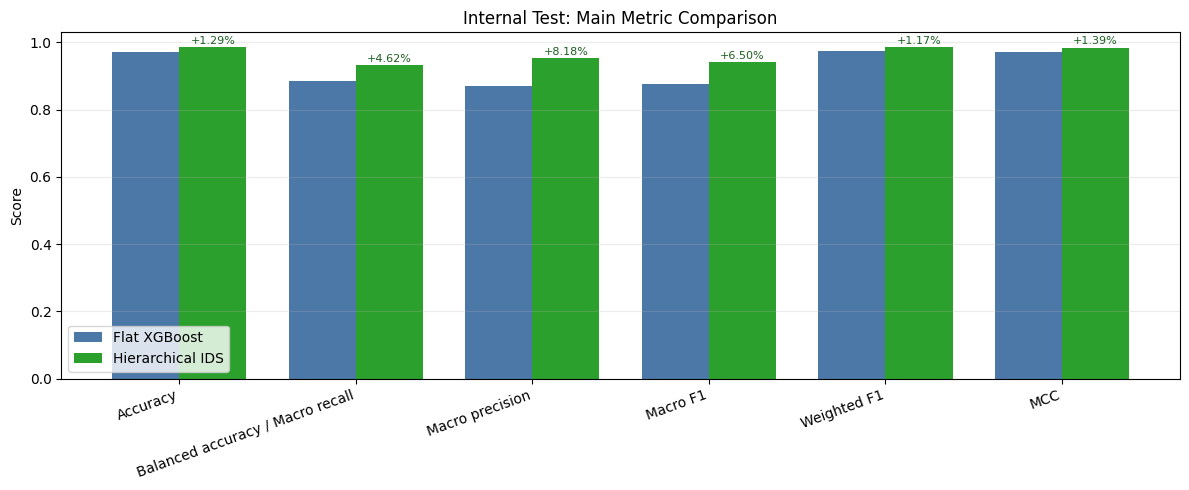

Saved figure: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\ablation\figures\internal_test_final_main_metric_comparison.png


In [4]:
metrics_for_plot = ["Accuracy", "Balanced accuracy / Macro recall", "Macro precision", "Macro F1", "Weighted F1", "MCC"]
plot_df = improvement_df[improvement_df["Metric"].isin(metrics_for_plot)].copy()
x = np.arange(len(plot_df))
width = 0.38
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width / 2, plot_df["Flat XGBoost"], width, label="Flat XGBoost", color="#4c78a8")
ax.bar(x + width / 2, plot_df["Hierarchical IDS"], width, label="Hierarchical IDS", color="#2ca02c")
ax.set_xticks(x, plot_df["Metric"], rotation=20, ha="right")
ax.set_ylim(0, 1.03)
ax.set_ylabel("Score")
ax.set_title("Internal Test: Main Metric Comparison")
ax.grid(axis="y", alpha=0.25)
ax.legend()
for idx, row in plot_df.iterrows():
    loc = list(plot_df.index).index(idx)
    ax.text(loc + width / 2, row["Hierarchical IDS"] + 0.01, f"+{row['Absolute gain']:.2%}", ha="center", fontsize=8, color="#1b5e20")
save_and_show(fig, FIGURES_DIR / "internal_test_final_main_metric_comparison.png")


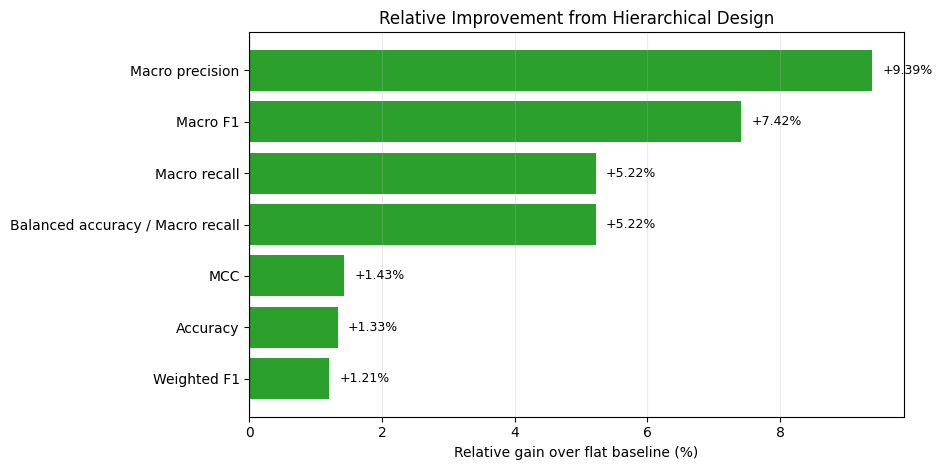

Saved figure: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\ablation\figures\internal_test_final_relative_improvement.png


In [5]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
rel_df = improvement_df.sort_values("Relative gain (%)")
colors = np.where(rel_df["Relative gain (%)"] >= 0, "#2ca02c", "#d62728")
ax.barh(rel_df["Metric"], rel_df["Relative gain (%)"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Relative gain over flat baseline (%)")
ax.set_title("Relative Improvement from Hierarchical Design")
ax.grid(axis="x", alpha=0.25)
for y, value in enumerate(rel_df["Relative gain (%)"]):
    ax.text(value + 0.15, y, f"{value:+.2f}%", va="center", fontsize=9)
save_and_show(fig, FIGURES_DIR / "internal_test_final_relative_improvement.png")


**Interpretation.** The largest reviewer-facing improvement is macro-F1, not only accuracy. That supports the claim that staged specialization improves difficult classes rather than just following the majority distribution.


## 4. Per-Class F1 Gains

Positive delta means the hierarchy wins that class. This is the most direct evidence for where the design helps.


In [6]:
per_class = per_class_df.copy()
per_class["delta_f1_pp"] = per_class["delta_f1"] * 100.0
per_class["relative_delta_f1_pct"] = np.where(per_class["flat_f1"] > 0, per_class["delta_f1"] / per_class["flat_f1"] * 100.0, np.nan)
per_class.to_csv(INTERNAL_DIR / "internal_test_per_class_f1_improvements.csv", index=False)

top_hier = per_class.sort_values("delta_f1", ascending=False).head(12)
top_flat = per_class.sort_values("delta_f1", ascending=True).head(8)
show_table("Largest hierarchical per-class F1 gains", top_hier[["label", "flat_f1", "hier_f1", "delta_f1", "relative_delta_f1_pct", "hier_support"]], percent_cols=["flat_f1", "hier_f1", "delta_f1"])
show_table("Classes where flat is closest or better", top_flat[["label", "flat_f1", "hier_f1", "delta_f1", "relative_delta_f1_pct", "hier_support"]], percent_cols=["flat_f1", "hier_f1", "delta_f1"])
show_table("Per-class winner count", per_class["winner"].value_counts().rename_axis("Winner").reset_index(name="Classes"))


**Largest hierarchical per-class F1 gains**

,label,flat_f1,hier_f1,delta_f1,relative_delta_f1_pct,hier_support
17,DictionaryBruteForce,60.35%,90.65%,30.29%,50.188524,2613.0
33,XSS,56.63%,86.19%,29.56%,52.208311,790.0
0,Backdoor_Malware,61.24%,87.14%,25.89%,42.278601,639.0
3,CommandInjection,63.13%,87.89%,24.76%,39.210488,1070.0
2,BrowserHijacking,67.61%,89.18%,21.57%,31.906692,1150.0
31,Uploading_Attack,62.18%,82.78%,20.60%,33.129984,226.0
28,Recon-PingSweep,57.75%,73.15%,15.40%,26.675576,412.0
27,Recon-OSScan,68.94%,82.70%,13.76%,19.966613,19818.0
29,Recon-PortScan,72.34%,85.87%,13.53%,18.705050,16262.0
22,MITM-ArpSpoofing,79.95%,90.15%,10.20%,12.756791,6704.0


**Classes where flat is closest or better**

,label,flat_f1,hier_f1,delta_f1,relative_delta_f1_pct,hier_support
30,SqlInjection,67.53%,64.62%,-2.91%,-4.302789,1091.0
19,DoS-SYN_Flood,99.95%,99.90%,-0.05%,-0.052617,44598.0
13,DDoS-TCP_Flood,99.97%,99.97%,-0.00%,-0.002043,98671.0
8,DDoS-PSHACK_Flood,100.00%,100.00%,-0.00%,-0.001665,90111.0
20,DoS-TCP_Flood,99.95%,99.95%,0.00%,0.000044,59219.0
6,DDoS-ICMP_Flood,100.00%,100.00%,0.00%,0.000315,158548.0
4,DDoS-ACK_Fragmentation,99.98%,99.98%,0.00%,0.001758,56937.0
25,Mirai-udpplain,100.00%,100.00%,0.00%,0.002542,19673.0


**Per-class winner count**

,Winner,Classes
0,hierarchical,30
1,flat,4


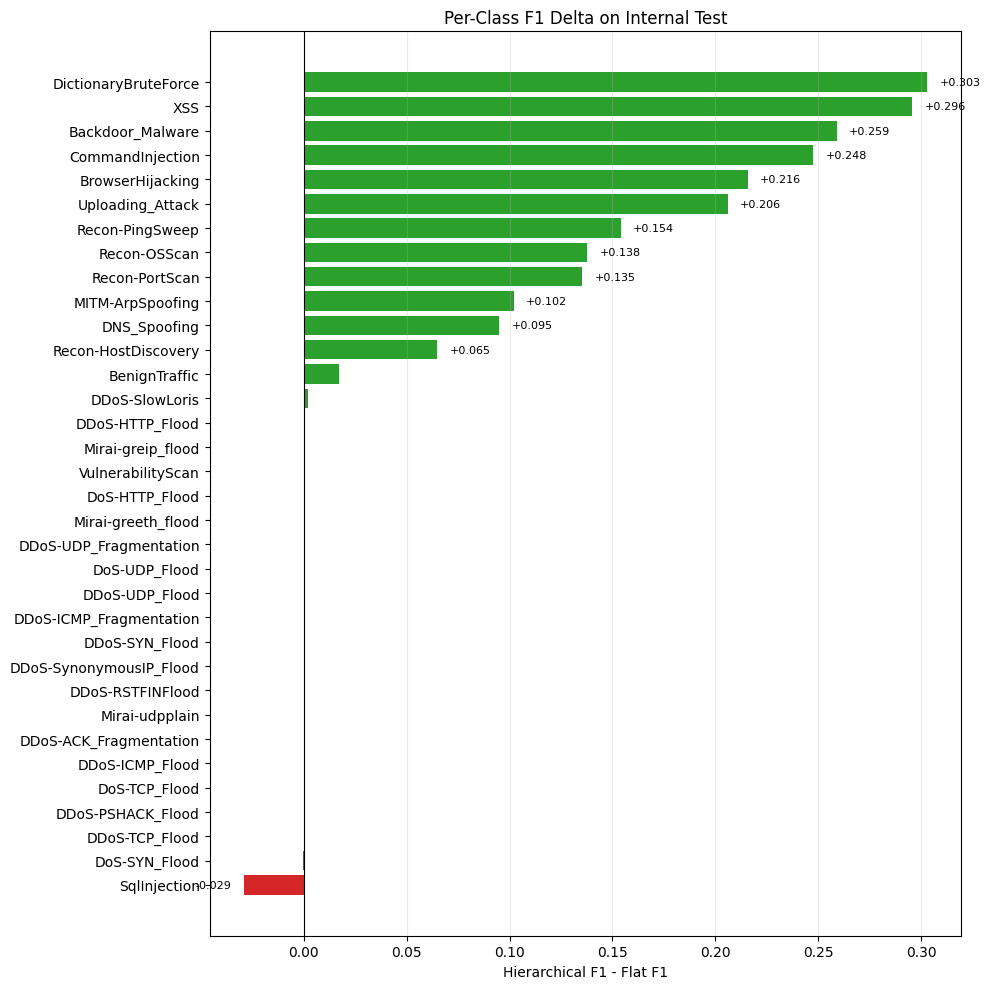

Saved figure: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\ablation\figures\internal_test_final_per_class_delta_f1.png


In [7]:
plot_df = per_class.sort_values("delta_f1")
fig, ax = plt.subplots(figsize=(10, 10))
colors = np.where(plot_df["delta_f1"] >= 0, "#2ca02c", "#d62728")
ax.barh(plot_df["label"], plot_df["delta_f1"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Hierarchical F1 - Flat F1")
ax.set_title("Per-Class F1 Delta on Internal Test")
ax.grid(axis="x", alpha=0.25)
for y, value in enumerate(plot_df["delta_f1"]):
    if abs(value) >= 0.02:
        ax.text(value + (0.006 if value >= 0 else -0.006), y, f"{value:+.3f}", va="center", ha="left" if value >= 0 else "right", fontsize=8)
save_and_show(fig, FIGURES_DIR / "internal_test_final_per_class_delta_f1.png")


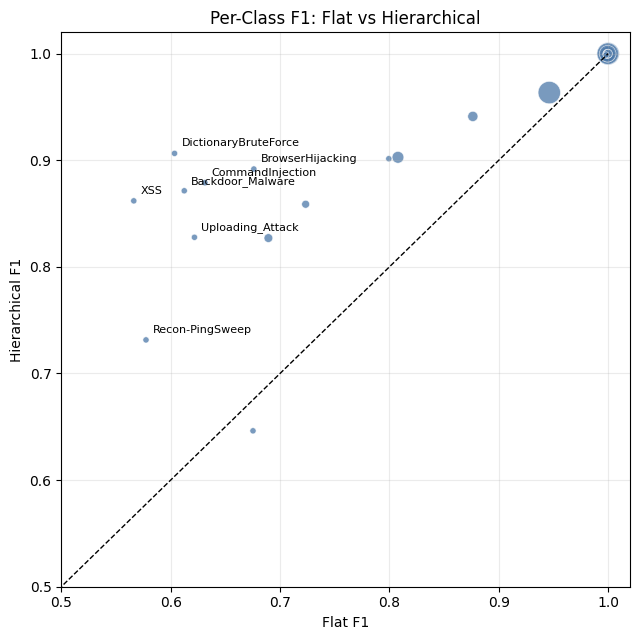

Saved figure: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\ablation\figures\internal_test_final_flat_vs_hier_f1_scatter.png


In [8]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(per_class["flat_f1"], per_class["hier_f1"], s=np.clip(per_class["hier_support"] / 500, 20, 260), alpha=0.75, color="#4c78a8", edgecolor="white", linewidth=0.5)
ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
ax.set_xlim(0.5, 1.02)
ax.set_ylim(0.5, 1.02)
ax.set_xlabel("Flat F1")
ax.set_ylabel("Hierarchical F1")
ax.set_title("Per-Class F1: Flat vs Hierarchical")
ax.grid(alpha=0.25)
for _, row in per_class.sort_values("delta_f1", ascending=False).head(7).iterrows():
    ax.annotate(row["label"], (row["flat_f1"], row["hier_f1"]), xytext=(5, 5), textcoords="offset points", fontsize=8)
save_and_show(fig, FIGURES_DIR / "internal_test_final_flat_vs_hier_f1_scatter.png")


**Interpretation.** The biggest gains are concentrated in rare and difficult subclasses such as DictionaryBruteForce, XSS, Backdoor_Malware, CommandInjection, BrowserHijacking, Uploading_Attack, and Recon variants.


## 5. Security-Segment Strengths

Grouping classes by security meaning makes the improvement easier to explain in the paper.


In [9]:
labels = set(per_class["label"])
segments = {
    "Rare web/injection": ["Backdoor_Malware", "BrowserHijacking", "CommandInjection", "SqlInjection", "Uploading_Attack", "XSS"],
    "Reconnaissance": ["Recon-HostDiscovery", "Recon-OSScan", "Recon-PingSweep", "Recon-PortScan", "VulnerabilityScan"],
    "Spoofing/MITM": ["DNS_Spoofing", "MITM-ArpSpoofing"],
    "Brute force": ["DictionaryBruteForce"],
    "High-volume DDoS/DoS/Mirai": [label for label in labels if label.startswith("DDoS-") or label.startswith("DoS-") or label.startswith("Mirai-")],
    "Benign": ["BenignTraffic"],
}
segment_rows = []
for segment, segment_labels in segments.items():
    present = [label for label in segment_labels if label in labels]
    sub = per_class[per_class["label"].isin(present)]
    if sub.empty:
        continue
    segment_rows.append({
        "Segment": segment,
        "Classes": len(sub),
        "Support": int(sub["hier_support"].sum()),
        "Flat macro F1": sub["flat_f1"].mean(),
        "Hier macro F1": sub["hier_f1"].mean(),
        "Macro F1 gain": sub["hier_f1"].mean() - sub["flat_f1"].mean(),
        "Flat weighted F1": np.average(sub["flat_f1"], weights=sub["hier_support"]),
        "Hier weighted F1": np.average(sub["hier_f1"], weights=sub["hier_support"]),
    })
segment_df = pd.DataFrame(segment_rows).sort_values("Macro F1 gain", ascending=False)
segment_df.to_csv(INTERNAL_DIR / "internal_test_security_segment_improvements.csv", index=False)
show_table("Security-segment F1 comparison", segment_df, percent_cols=["Flat macro F1", "Hier macro F1", "Macro F1 gain", "Flat weighted F1", "Hier weighted F1"])


**Security-segment F1 comparison**

,Segment,Classes,Support,Flat macro F1,Hier macro F1,Macro F1 gain,Flat weighted F1,Hier weighted F1
3,Brute force,1,2613,60.35%,90.65%,30.29%,60.35%,90.65%
0,Rare web/injection,6,4966,63.05%,82.97%,19.91%,63.81%,82.48%
1,Reconnaissance,5,70913,77.29%,87.14%,9.85%,80.02%,89.53%
2,Spoofing/MITM,2,42569,80.37%,90.21%,9.85%,80.65%,90.26%
5,Benign,1,219639,94.62%,96.35%,1.73%,94.62%,96.35%
4,High-volume DDoS/DoS/Mirai,19,1059299,99.94%,99.97%,0.03%,99.97%,99.98%


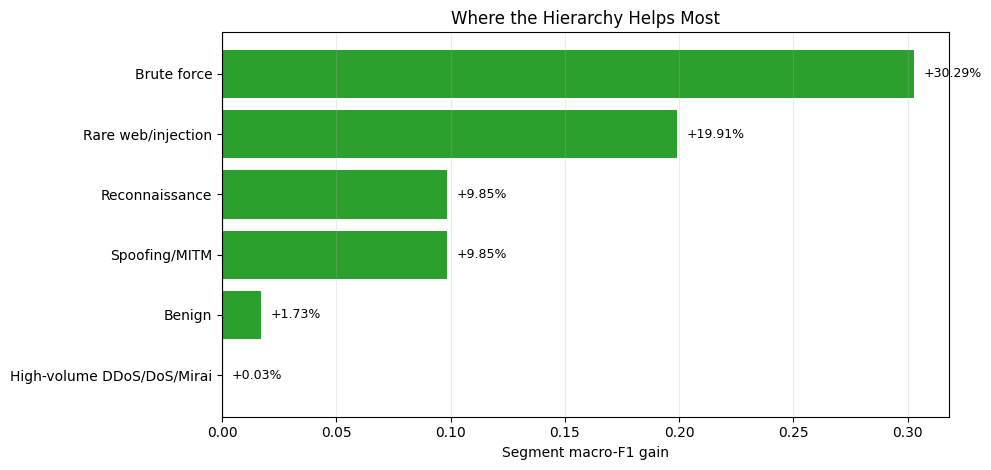

Saved figure: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\ablation\figures\internal_test_final_segment_gains.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 4.8))
seg = segment_df.sort_values("Macro F1 gain")
colors = np.where(seg["Macro F1 gain"] >= 0, "#2ca02c", "#d62728")
ax.barh(seg["Segment"], seg["Macro F1 gain"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Segment macro-F1 gain")
ax.set_title("Where the Hierarchy Helps Most")
ax.grid(axis="x", alpha=0.25)
for y, value in enumerate(seg["Macro F1 gain"]):
    ax.text(value + (0.004 if value >= 0 else -0.004), y, f"{value:+.2%}", va="center", ha="left" if value >= 0 else "right", fontsize=9)
save_and_show(fig, FIGURES_DIR / "internal_test_final_segment_gains.png")


**Interpretation.** The hierarchy is especially stronger in rare web/injection, brute-force, spoofing, and reconnaissance subclasses. This is the clearest design-level advantage over a single flat classifier.


## 6. Row-Level Win/Loss Analysis

This shows whether the hierarchy fixes flat-model mistakes or simply moves errors around.


In [11]:
flat_correct = flat_pred == y_true
hier_correct = y_pred == y_true
outcome = pd.Series(np.select(
    [flat_correct & hier_correct, ~flat_correct & hier_correct, flat_correct & ~hier_correct, ~flat_correct & ~hier_correct],
    ["both_correct", "hier_only_correct", "flat_only_correct", "both_wrong"],
    default="unknown",
), name="outcome")
outcome_df = outcome.value_counts().rename_axis("Outcome").reset_index(name="Rows")
outcome_df["Share"] = outcome_df["Rows"] / outcome_df["Rows"].sum()
outcome_df.to_csv(INTERNAL_DIR / "internal_test_row_level_win_loss.csv", index=False)
show_table("Row-level model outcome overlap", outcome_df, percent_cols=["Share"])
display(Markdown(
    f"**Reading:** The hierarchy uniquely fixes **{int(outcome_df.loc[outcome_df['Outcome'].eq('hier_only_correct'), 'Rows'].sum()):,}** rows that the flat model missed, "
    f"while the flat model uniquely fixes **{int(outcome_df.loc[outcome_df['Outcome'].eq('flat_only_correct'), 'Rows'].sum()):,}** rows."
))


**Row-level model outcome overlap**

,Outcome,Rows,Share
0,both_correct,1355442,96.82%
1,hier_only_correct,23816,1.70%
2,both_wrong,15049,1.07%
3,flat_only_correct,5692,0.41%


**Reading:** The hierarchy uniquely fixes **23,816** rows that the flat model missed, while the flat model uniquely fixes **5,692** rows.

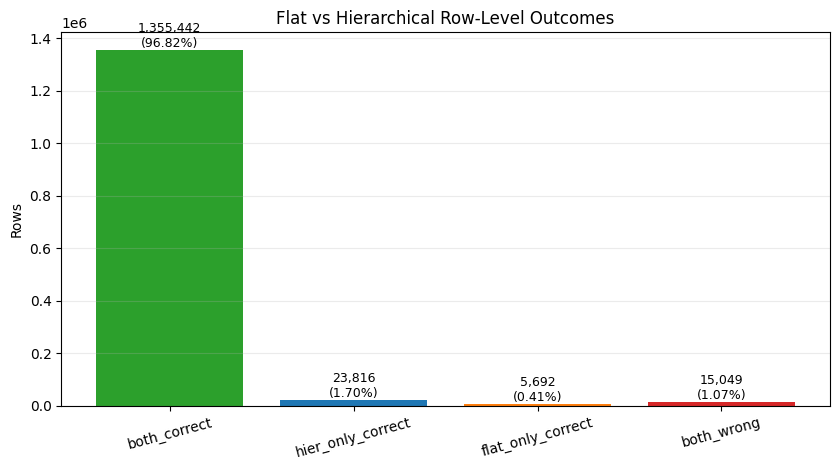

Saved figure: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\ablation\figures\internal_test_final_row_level_outcomes.png


In [12]:
order = ["both_correct", "hier_only_correct", "flat_only_correct", "both_wrong"]
plot_df = outcome_df.set_index("Outcome").reindex(order).fillna(0).reset_index()
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.bar(plot_df["Outcome"], plot_df["Rows"], color=["#2ca02c", "#1f77b4", "#ff7f0e", "#d62728"])
ax.set_ylabel("Rows")
ax.set_title("Flat vs Hierarchical Row-Level Outcomes")
ax.grid(axis="y", alpha=0.25)
ax.tick_params(axis="x", rotation=15)
for idx, row in enumerate(plot_df.itertuples(index=False)):
    ax.text(idx, row.Rows, f"{int(row.Rows):,}\n({row.Share:.2%})", ha="center", va="bottom", fontsize=9)
save_and_show(fig, FIGURES_DIR / "internal_test_final_row_level_outcomes.png")


**Interpretation.** A strong ablation result should show many `hier_only_correct` rows. That means the hierarchy recovers errors made by the flat baseline.


## 7. Runtime Trade-Off and Binary Context

The hierarchy is more accurate but slower because it executes multiple stage models for attack traffic.


**Inference runtime comparison**

,model,elapsed_seconds,us_per_flow
0,Flat 34-class XGBoost,5.094334,3.638812
1,Hierarchical IDS,29.115637,20.796898


**Reading:** The hierarchy is **5.72x slower** per flow than flat XGBoost. This runtime cost should be reported next to the accuracy and macro-F1 gains.

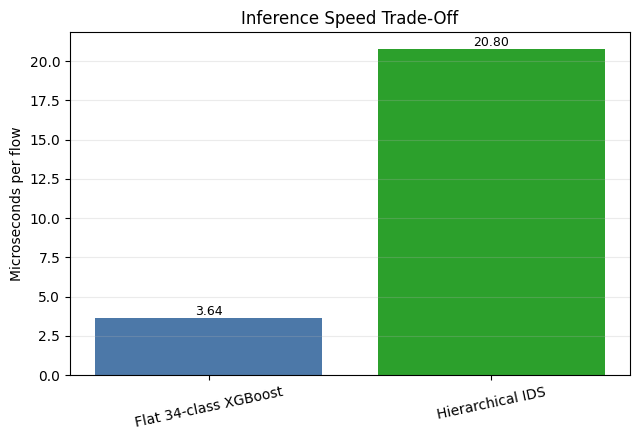

Saved figure: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\ablation\figures\internal_test_final_speed_tradeoff.png


In [13]:
speed_df = summary_df[["model", "elapsed_seconds", "us_per_flow"]].copy()
speed_ratio = float(hier_row["us_per_flow"]) / float(flat_row["us_per_flow"])
show_table("Inference runtime comparison", speed_df)
display(Markdown(
    f"**Reading:** The hierarchy is **{speed_ratio:.2f}x slower** per flow than flat XGBoost. "
    "This runtime cost should be reported next to the accuracy and macro-F1 gains."
))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(speed_df["model"], speed_df["us_per_flow"], color=["#4c78a8", "#2ca02c"])
ax.set_ylabel("Microseconds per flow")
ax.set_title("Inference Speed Trade-Off")
ax.grid(axis="y", alpha=0.25)
for idx, value in enumerate(speed_df["us_per_flow"]):
    ax.text(idx, value, f"{value:.2f}", ha="center", va="bottom", fontsize=9)
ax.tick_params(axis="x", rotation=12)
save_and_show(fig, FIGURES_DIR / "internal_test_final_speed_tradeoff.png")


In [14]:
show_table("Binary gate audit used by the hierarchy", binary_gate_df, percent_cols=["accuracy", "macro_f1", "attack_precision", "attack_recall", "attack_miss_rate", "false_alarm_rate", "mcc"])
display(Markdown(
    f"**Reading:** The binary gate has **{binary_gate_df.loc[0, 'macro_f1']:.2%} macro-F1** and zero mismatches versus the saved binary-stage artifact."
))


**Binary gate audit used by the hierarchy**

,threshold,TN,FP,FN,TP,accuracy,macro_f1,attack_precision,attack_recall,attack_miss_rate,false_alarm_rate,mcc,saved_binary_prediction_mismatches,saved_binary_prob_max_abs_diff
0,0.454,213074,6565,9587,1170773,98.85%,97.83%,99.44%,99.19%,0.81%,2.99%,95.67%,0,0.000001


**Reading:** The binary gate has **97.83% macro-F1** and zero mismatches versus the saved binary-stage artifact.

## 8. Final Audit and Paper-Ready Summary

The assertions below make sure the final comparison remains internally consistent.


In [15]:
assert int(binary_gate_df.loc[0, "saved_binary_prediction_mismatches"]) == 0
assert float(hier_row["macro_f1"]) > float(flat_row["macro_f1"]), "Hierarchy should beat flat on macro-F1."
assert float(hier_row["accuracy"]) > float(flat_row["accuracy"]), "Hierarchy should beat flat on accuracy."
assert len(y_true) == int(flat_row["rows"]) == int(hier_row["rows"])
assert outcome_df["Rows"].sum() == len(y_true)

paper_summary = (
    f"Hierarchical IDS achieves {hier_row['accuracy']:.2%} accuracy and {hier_row['macro_f1']:.2%} macro-F1 "
    f"versus {flat_row['accuracy']:.2%} accuracy and {flat_row['macro_f1']:.2%} macro-F1 for flat 34-class XGBoost. "
    f"The macro-F1 gain is {(hier_row['macro_f1'] - flat_row['macro_f1']):.2%} absolute "
    f"({((hier_row['macro_f1'] - flat_row['macro_f1']) / flat_row['macro_f1'] * 100):.2f}% relative)."
)
display(Markdown("**Paper-ready result:** " + paper_summary))
print("Audit passed.")


**Paper-ready result:** Hierarchical IDS achieves 98.52% accuracy and 94.13% macro-F1 versus 97.22% accuracy and 87.63% macro-F1 for flat 34-class XGBoost. The macro-F1 gain is 6.50% absolute (7.42% relative).

Audit passed.


**Conclusion.** This notebook is the final internal-test ablation comparison. It uses identical test rows for both systems and reports main metrics, per-class gains, security-segment gains, row-level win/loss outcomes, and runtime trade-off.
